1. Introduction

This project focuses on customer segmentation using machine learning techniques.The goal is to group customers based on their purchasing behavior to help businesses
make better marketing decisions.

2. Dataset Description

The dataset contains customer demographic and purchasing behavior data.

Important features:
- Income: Annual income of customer
- Age: Age of the customer
- MntTotal: Total amount spent
- NumPurchases: Total purchases
- Engagement: Interaction level with website

In [101]:
import pandas as pd
data = pd.read_csv('ifood_df.csv')
data.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


3. Data Exploration

In this step, we explore the dataset structure, columns, and basic information.

In [102]:
data.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [103]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [104]:
data.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


4. Feature Engineering

Creating new features to improve clustering performance.

In [105]:
data['Total_Purchases'] = (
    data['NumWebPurchases'] +
    data['NumCatalogPurchases'] +
    data['NumStorePurchases']
)
data['Engagement'] = data['Total_Purchases'] / (data['NumWebVisitsMonth'] + 1)

5. Data Preparation

Selecting important features and scaling the data for clustering.

In [106]:
X = data[['Income', 'Age', 'MntTotal', 'Total_Purchases', 'Engagement']]

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

6. K-Means Clustering

Applying K-Means algorithm to segment customers into groups.

In [108]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

7. Visualization

Visualizing customer segments using scatter plots and box plots.

<Axes: xlabel='Income', ylabel='MntTotal'>

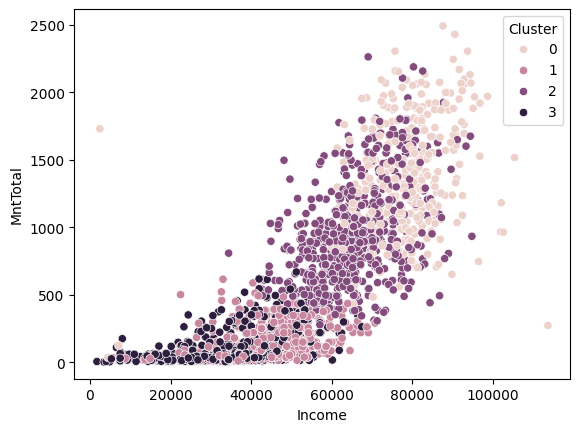

In [109]:
import seaborn as sns
sns.scatterplot(
    x=data['Income'],
    y=data['MntTotal'],
    hue=data['Cluster']
)

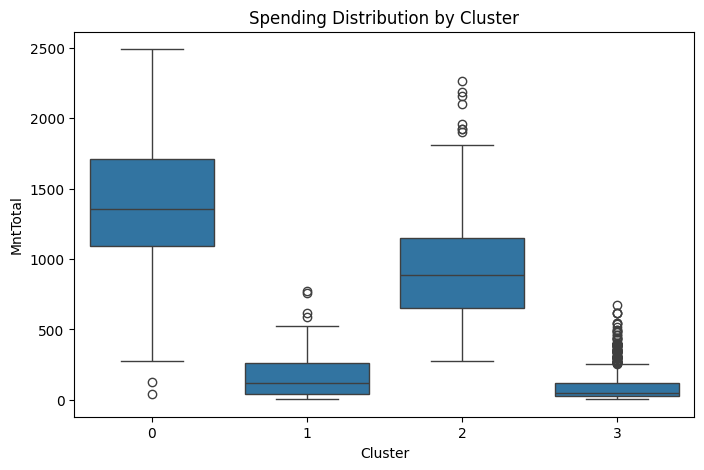

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='MntTotal', data=data)
plt.title('Spending Distribution by Cluster')
plt.show()

8. Cluster Analysis

Analyzing the characteristics of each cluster.

In [111]:
data.groupby('Cluster')[[
    'Income',
    'MntTotal',
    'Total_Purchases',
    'Engagement',
    'Response'
]].mean()

,Income,MntTotal,Total_Purchases,Engagement,Response
Cluster,,,,,
0,78328.575419,1388.829609,20.360335,7.215032,0.287709
1,42745.347548,163.388060,8.006397,1.254108,0.072495
2,65278.204082,928.711146,18.740973,3.536740,0.166405
3,32598.252362,101.858300,6.388664,0.873503,0.121457


Insights and Recommendations

- Cluster 0: High income and high spending customers → Target with premium products
- Cluster 1: Moderate income and low spending → Encourage engagement with offers
- Cluster 2: High income but selective spending → Provide personalized recommendations
- Cluster 3: Low income and low spending → Focus on discounts and promotions

These insights help businesses improve marketing strategies and customer targeting.